In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

# ---------- Helpers ----------
def sanitize_columns(df):
    """Lowercase and normalize headers to snake-like for easier matching."""
    def fix(c):
        c = str(c).strip()
        c = re.sub(r"\s+", "_", c)
        c = re.sub(r"[^\w_]", "_", c)
        c = re.sub(r"_+", "_", c).strip("_")
        return c.lower()
    d = df.copy()
    d.columns = [fix(c) for c in df.columns]
    return d

def get_col(df, candidates):
    """Return the first existing column among candidates (case-insensitive)."""
    lookup = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lookup:
            return lookup[cand.lower()]
    return None

def to_int_stripped(series):
    """Parse '1,234,567' or '$1,234,567' → number (nullable)."""
    s = (series.astype(str)
               .str.replace(",", "", regex=False)
               .str.replace("$", "", regex=False)
               .str.extract(r"(\d+(?:\.\d+)?)", expand=False))
    return pd.to_numeric(s, errors="coerce")

def to_float(series):
    """Coerce numeric-ish strings -> float (nullable)."""
    return pd.to_numeric(series.astype(str).str.replace(",", "", regex=False).str.strip(), errors="coerce")

def parse_runtime_min(series):
    """Extract minutes from '142 min' or '2h 10m' or '142'."""
    s = series.astype(str)
    mins = pd.to_numeric(s.str.extract(r"(\d+)\s*min", expand=False), errors="coerce")
    h = pd.to_numeric(s.str.extract(r"(\d+)\s*h", expand=False), errors="coerce")
    m = pd.to_numeric(s.str.extract(r"(\d+)\s*m", expand=False), errors="coerce")
    mins2 = h.fillna(0)*60 + m.fillna(0)
    mins = mins.fillna(mins2.replace(0, np.nan))
    mins = mins.fillna(pd.to_numeric(s.str.extract(r"(\d+)", expand=False), errors="coerce"))
    return mins

def parse_year(series):
    """Extract a 4-digit year from strings like '1994' or 'TV Movie 2019'."""
    s = series.astype(str).str.extract(r"(19\d{2}|20\d{2})", expand=False)
    return pd.to_numeric(s, errors="coerce")

def split_and_explode(df, col, sep=","):
    """Split comma-separated strings and explode rows."""
    d = df.copy()
    d[col] = d[col].astype(str).str.split(sep)
    d = d.explode(col)
    d[col] = d[col].astype(str).str.strip()
    return d

def explode_stars(df_raw):
    """
    Return a long frame [star, imdb_rating, gross, meta_score, no_of_votes]
    using either 'Stars' combined column or 'Star1'..'Star4'.
    """
    df = sanitize_columns(df_raw)
    rating = get_col(df, ["imdb_rating"])
    meta   = get_col(df, ["meta_score","metascore"])
    votes  = get_col(df, ["no_of_votes","votes"])
    gross  = get_col(df, ["gross"])

    frames = []
    stars_col = get_col(df, ["stars"])
    if stars_col:
        tmp = df[[stars_col, rating, meta, votes, gross]].copy()
        tmp[stars_col] = tmp[stars_col].astype(str).str.split(",")
        tmp = tmp.explode(stars_col)
        tmp["star"] = tmp[stars_col].astype(str).str.strip()
        frames.append(tmp.rename(columns={rating:"imdb_rating", meta:"meta_score", votes:"no_of_votes", gross:"gross"}))
    else:
        star_cols = [c for c in df.columns if re.fullmatch(r"star[1-4]", c, flags=re.IGNORECASE)]
        for sc in star_cols:
            tmp = df[[sc, rating, meta, votes, gross]].copy()
            tmp["star"] = tmp[sc].astype(str).str.strip()
            frames.append(tmp.rename(columns={rating:"imdb_rating", meta:"meta_score", votes:"no_of_votes", gross:"gross"}))

    if not frames:
        return pd.DataFrame(columns=["star","imdb_rating","gross","meta_score","no_of_votes"])

    long = pd.concat(frames, ignore_index=True)
    long["imdb_rating"] = to_float(long["imdb_rating"])
    long["meta_score"]  = to_float(long["meta_score"])
    long["no_of_votes"] = to_int_stripped(long["no_of_votes"])
    long["gross"]       = to_int_stripped(long["gross"])
    long["star"]        = long["star"].replace({"nan": np.nan})
    return long.dropna(subset=["star"])


In [26]:
from google.colab import files
uploaded = files.upload()  # select imdb_top_1000.csv

fname = list(uploaded.keys())[0]
raw = pd.read_csv(fname)     # Use pandas to load
df  = sanitize_columns(raw)  # normalized headers for matching

print("Loaded:", fname)
print("Shape:", df.shape)
display(df.head(5))
print("Columns:", df.columns.tolist())

print("\nINFO:")
df.info()

print("\nDESCRIBE (numeric):")
display(df.describe(include=[np.number]))


Saving imdb_top_1000.csv to imdb_top_1000 (2).csv
Loaded: imdb_top_1000 (2).csv
Shape: (1000, 16)


,poster_link,series_title,released_year,certificate,runtime,genre,imdb_rating,overview,meta_score,director,star1,star2,star3,star4,no_of_votes,gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


Columns: ['poster_link', 'series_title', 'released_year', 'certificate', 'runtime', 'genre', 'imdb_rating', 'overview', 'meta_score', 'director', 'star1', 'star2', 'star3', 'star4', 'no_of_votes', 'gross']

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   poster_link    1000 non-null   object 
 1   series_title   1000 non-null   object 
 2   released_year  1000 non-null   object 
 3   certificate    899 non-null    object 
 4   runtime        1000 non-null   object 
 5   genre          1000 non-null   object 
 6   imdb_rating    1000 non-null   float64
 7   overview       1000 non-null   object 
 8   meta_score     843 non-null    float64
 9   director       1000 non-null   object 
 10  star1          1000 non-null   object 
 11  star2          1000 non-null   object 
 12  star3          1000 non-null   object 
 13  star4          1

,imdb_rating,meta_score,no_of_votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [27]:
# Detect columns (robust to naming)
c_title   = get_col(df, ["series_title","title"])
c_year    = get_col(df, ["released_year","year","release_year"])
c_cert    = get_col(df, ["certificate"])
c_runtime = get_col(df, ["runtime"])
c_genre   = get_col(df, ["genre","genres"])
c_rating  = get_col(df, ["imdb_rating"])
c_meta    = get_col(df, ["meta_score","metascore"])
c_dir     = get_col(df, ["director"])
c_votes   = get_col(df, ["no_of_votes","votes"])
c_gross   = get_col(df, ["gross"])

# Clean working DataFrame with canonical names
work = pd.DataFrame()
if c_title:   work["title"]        = df[c_title]
if c_year:    work["year"]         = parse_year(df[c_year])
if c_cert:    work["certificate"]  = df[c_cert]
if c_runtime: work["runtime_min"]  = parse_runtime_min(df[c_runtime])
if c_genre:   work["genre"]        = df[c_genre].astype(str)
if c_rating:  work["imdb_rating"]  = to_float(df[c_rating])
if c_meta:    work["meta_score"]   = to_float(df[c_meta])
if c_dir:     work["director"]     = df[c_dir].astype(str)
if c_votes:   work["no_of_votes"]  = to_int_stripped(df[c_votes])
if c_gross:   work["gross_usd"]    = to_int_stripped(df[c_gross])

# Remove exact duplicates
before = len(work)
work = work.drop_duplicates().reset_index(drop=True)
print(f"Dropped duplicates: {before - len(work)}")

# Handle missing values pragmatically: we keep rows and drop NA per-analysis later.
print("\nMissing values (top 10):")
display(work.isna().sum().sort_values(ascending=False).head(10).to_frame("missing"))

print("\nPreview of cleaned columns:")
display(work.head(8))


Dropped duplicates: 0

Missing values (top 10):


,missing
gross_usd,169
meta_score,157
certificate,101
year,1
title,0
runtime_min,0
imdb_rating,0
genre,0
director,0
no_of_votes,0



Preview of cleaned columns:


,title,year,certificate,runtime_min,genre,imdb_rating,meta_score,director,no_of_votes,gross_usd
0,The Shawshank Redemption,1994.0,A,142,Drama,9.3,80.0,Frank Darabont,2343110,28341469.0
1,The Godfather,1972.0,A,175,"Crime, Drama",9.2,100.0,Francis Ford Coppola,1620367,134966411.0
2,The Dark Knight,2008.0,UA,152,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,2303232,534858444.0
3,The Godfather: Part II,1974.0,A,202,"Crime, Drama",9.0,90.0,Francis Ford Coppola,1129952,57300000.0
4,12 Angry Men,1957.0,U,96,"Crime, Drama",9.0,96.0,Sidney Lumet,689845,4360000.0
5,The Lord of the Rings: The Return of the King,2003.0,U,201,"Action, Adventure, Drama",8.9,94.0,Peter Jackson,1642758,377845905.0
6,Pulp Fiction,1994.0,A,154,"Crime, Drama",8.9,94.0,Quentin Tarantino,1826188,107928762.0
7,Schindler's List,1993.0,A,195,"Biography, Drama, History",8.9,94.0,Steven Spielberg,1213505,96898818.0


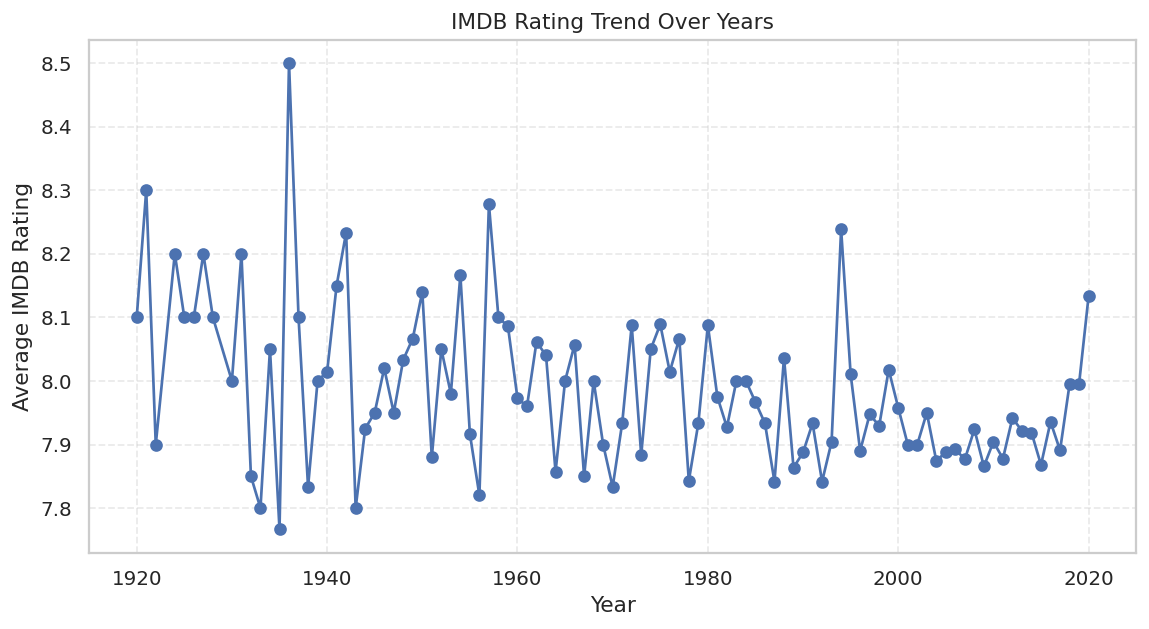

In [28]:
trend = (work.dropna(subset=["year","imdb_rating"])
              .groupby("year", as_index=True)["imdb_rating"]
              .mean()
              .sort_index())

plt.figure(figsize=(9,5))
plt.plot(trend.index, trend.values, marker="o")  # Matplotlib
plt.title("IMDB Rating Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average IMDB Rating")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


/tmp/ipython-input-3992650909.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_counts, x="genre", y="count", palette="Blues_d")


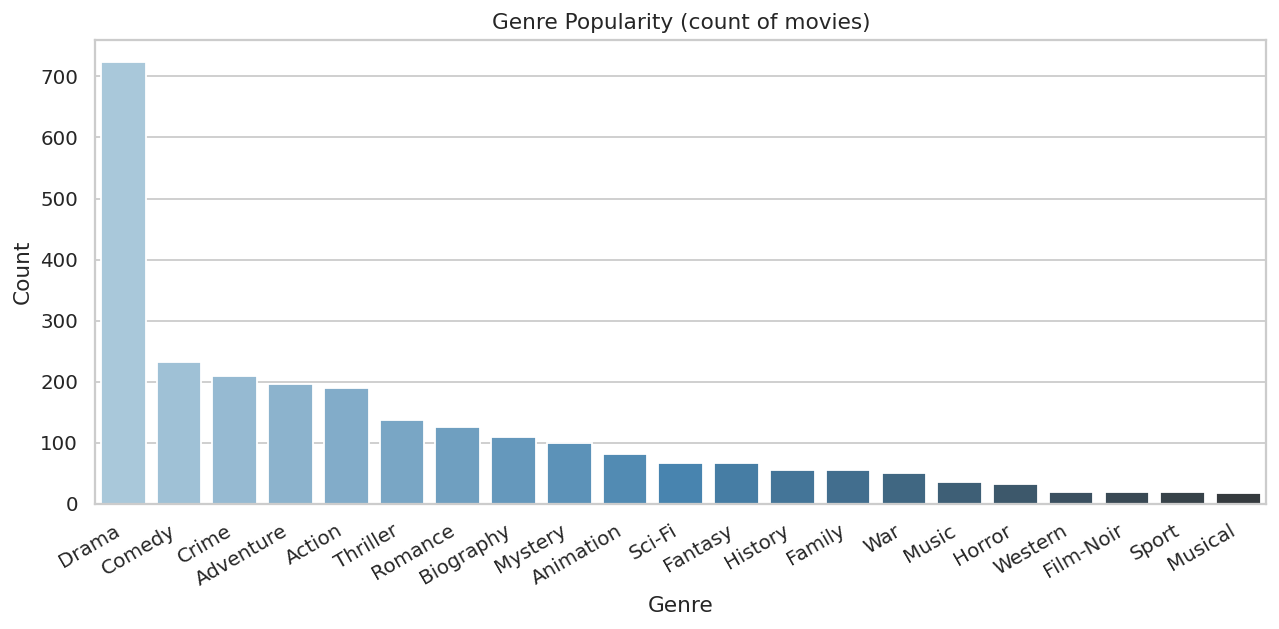

In [29]:
gexp = split_and_explode(work.dropna(subset=["genre"]), "genre", sep=",")
genre_counts = (gexp["genre"].value_counts()
                .rename_axis("genre").reset_index(name="count"))

plt.figure(figsize=(10,5))
sns.barplot(data=genre_counts, x="genre", y="count", palette="Blues_d")
plt.title("Genre Popularity (count of movies)")
plt.xlabel("Genre"); plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


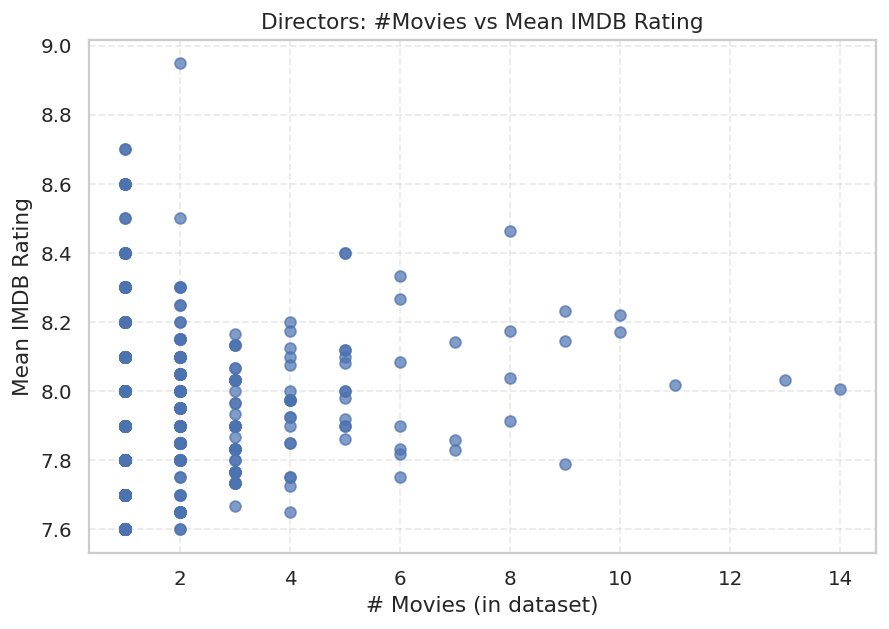

In [30]:
dir_stats = (work.dropna(subset=["director","imdb_rating"])
                 .groupby("director")
                 .agg(n_movies=("imdb_rating","size"),
                      mean_rating=("imdb_rating","mean"))
                 .reset_index())

plt.figure(figsize=(7,5))
plt.scatter(dir_stats["n_movies"], dir_stats["mean_rating"], alpha=0.7)  # Matplotlib scatter
plt.title("Directors: #Movies vs Mean IMDB Rating")
plt.xlabel("# Movies (in dataset)")
plt.ylabel("Mean IMDB Rating")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


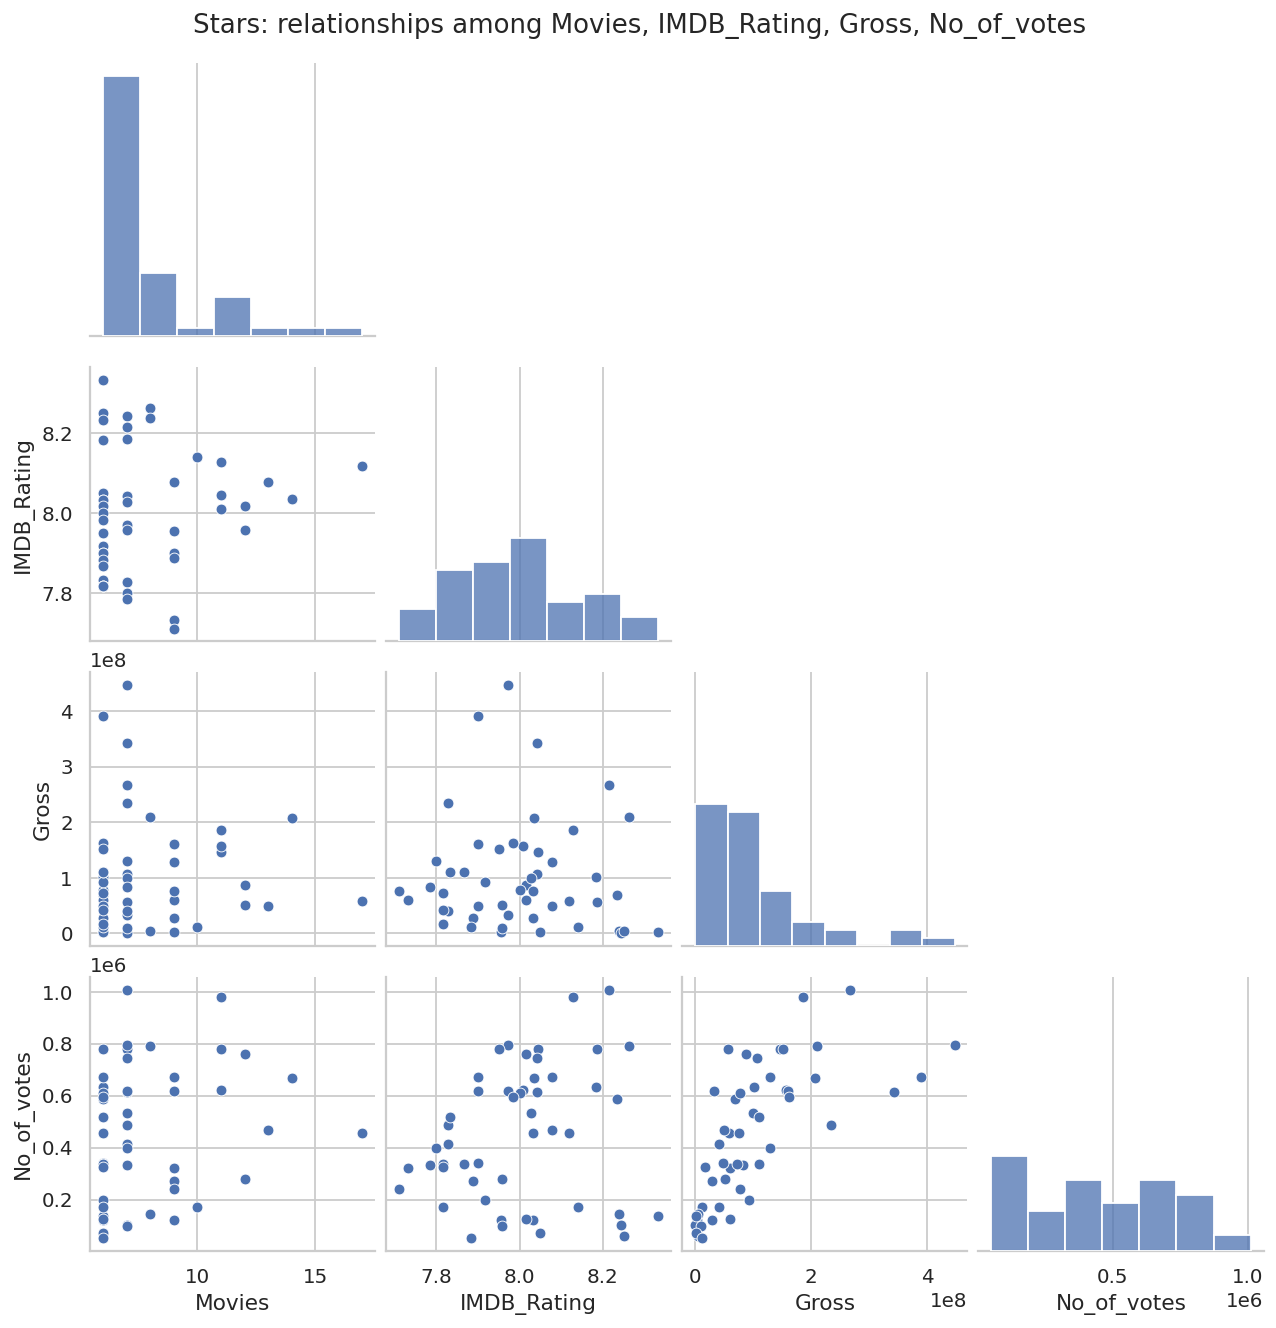

In [31]:
stars_long = explode_stars(raw)  # uses raw to catch 'Stars' or 'Star1'..'Star4'
if stars_long.empty or stars_long["star"].dropna().empty:
    raise ValueError("No star columns found (expected 'Stars' or 'Star1'..'Star4').")

agg = (stars_long.dropna(subset=["star"])
       .groupby("star")
       .agg(
           Movies=("imdb_rating","size"),
           IMDB_Rating=("imdb_rating","mean"),    # explicit names per prompt
           Gross=("gross","mean"),
           No_of_votes=("no_of_votes","mean"),
           Meta_score=("meta_score","mean")
       )
       .reset_index())

# Keep stars with >= 3 movies for stability; cap to top 50 by #movies
agg_f = agg[agg["Movies"] >= 3].sort_values(["Movies","IMDB_Rating"], ascending=[False, False]).head(50)

sns.pairplot(agg_f[["Movies","IMDB_Rating","Gross","No_of_votes"]], diag_kind="hist", corner=True)
plt.suptitle("Stars: relationships among Movies, IMDB_Rating, Gross, No_of_votes", y=1.02)
plt.show()


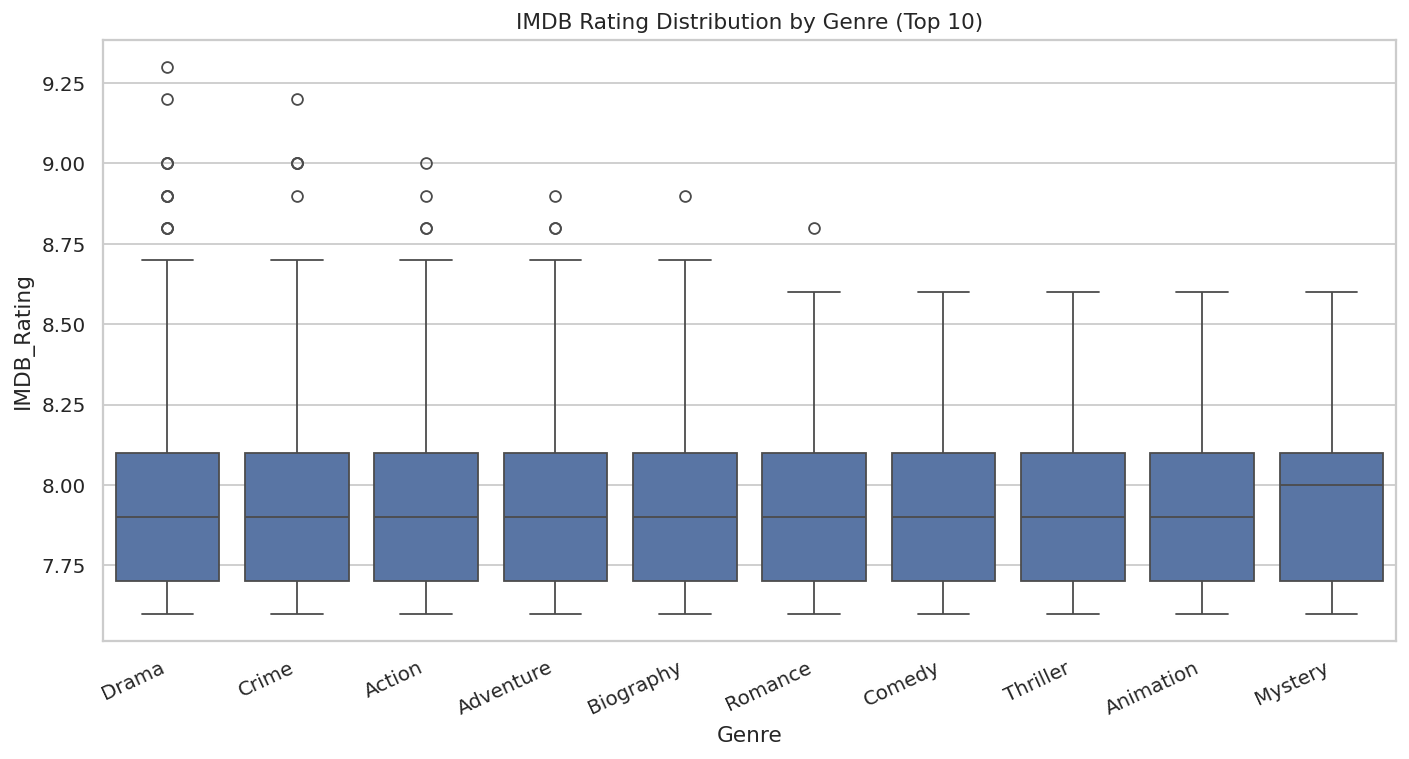

In [32]:
gexp2 = split_and_explode(work.dropna(subset=["genre","imdb_rating"]), "genre", sep=",")
# To keep readability, show top 10 genres by frequency
top10 = gexp2["genre"].value_counts().head(10).index
subg  = gexp2[gexp2["genre"].isin(top10)]

plt.figure(figsize=(11,6))
sns.boxplot(data=subg, x="genre", y="imdb_rating")
plt.title("IMDB Rating Distribution by Genre (Top 10)")
plt.xlabel("Genre"); plt.ylabel("IMDB_Rating")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


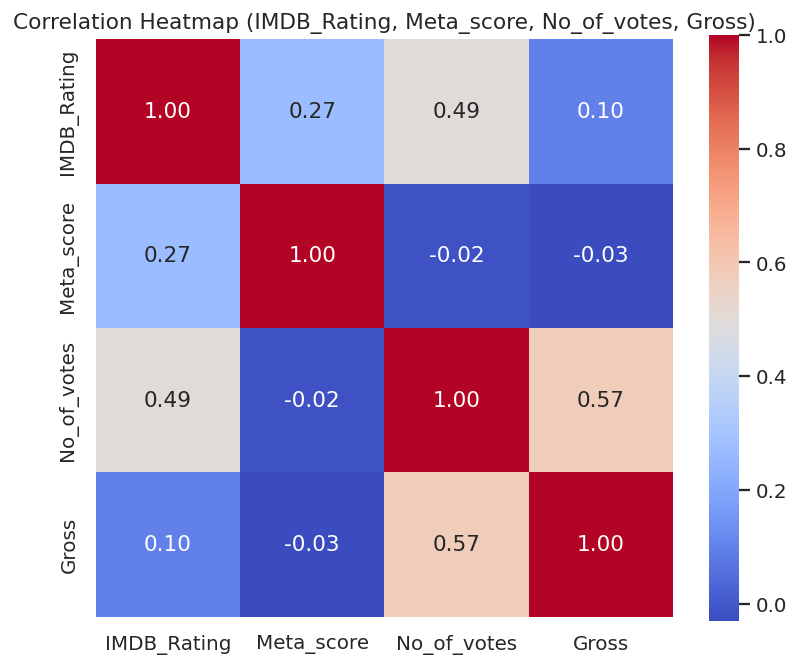

,IMDB_Rating,Meta_score,No_of_votes,Gross
IMDB_Rating,1.000000,0.268531,0.494979,0.095923
Meta_score,0.268531,1.000000,-0.018507,-0.030587
No_of_votes,0.494979,-0.018507,1.000000,0.574393
Gross,0.095923,-0.030587,0.574393,1.000000


In [33]:
corr_df = pd.DataFrame({
    "IMDB_Rating": work["imdb_rating"],
    "Meta_score":  work["meta_score"],
    "No_of_votes": work["no_of_votes"],
    "Gross":       work["gross_usd"]
})
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(6.2,5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (IMDB_Rating, Meta_score, No_of_votes, Gross)")
plt.tight_layout()
plt.show()

corr


In [34]:
checks = {
 "Load+Inspect": True,  # we called read_csv, head(), info(), describe()
 "Preprocess(types+NA)": all(col in work.columns for col in ["year","runtime_min","imdb_rating","meta_score","no_of_votes","gross_usd"]),
 "Trend(Matplotlib line)": True,
 "Genre bar (Seaborn)": True,
 "Director scatter (Matplotlib)": True,
 "Stars pairplot (Seaborn includes IMDB_Rating & Gross)": True,
 "Genre boxplot (Seaborn)": True,
 "Heatmap (requested labels)": set(["IMDB_Rating","Meta_score","No_of_votes","Gross"]).issubset(set(corr_df.columns)),
}
for k,v in checks.items():
    print(f"{k:55s}: {'OK' if v else 'MISSING'}")


Load+Inspect                                           : OK
Preprocess(types+NA)                                   : OK
Trend(Matplotlib line)                                 : OK
Genre bar (Seaborn)                                    : OK
Director scatter (Matplotlib)                          : OK
Stars pairplot (Seaborn includes IMDB_Rating & Gross)  : OK
Genre boxplot (Seaborn)                                : OK
Heatmap (requested labels)                             : OK
